In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from ipywidgets import VBox, HBox

import warnings
warnings.filterwarnings('ignore')

# Описание данных

In [2]:
df = pd.read_csv('mc1-reports-data.csv')
df.head()

,time,sewer_and_water,power,roads_and_bridges,medical,buildings,shake_intensity,location
0,2020-04-08 17:50:00,10.0,6.0,10.0,3.0,8.0,NaN,1
1,2020-04-09 13:50:00,2.0,10.0,0.0,8.0,4.0,0.0,1
2,2020-04-09 00:20:00,7.0,10.0,10.0,9.0,10.0,0.0,1
3,2020-04-08 17:25:00,1.0,1.0,2.0,10.0,7.0,NaN,1
4,2020-04-08 02:50:00,9.0,7.0,1.0,6.0,9.0,NaN,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83070 entries, 0 to 83069
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   time               83070 non-null  object 
 1   sewer_and_water    82899 non-null  float64
 2   power              83070 non-null  float64
 3   roads_and_bridges  83070 non-null  float64
 4   medical            35629 non-null  float64
 5   buildings          82900 non-null  float64
 6   shake_intensity    70926 non-null  float64
 7   location           83070 non-null  int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 5.1+ MB


Датасет `mc1-reports-data.csv` содержит 83 070 записей с временными метками, оценками ущерба по 5 категориям инфраструктуры, интенсивностью сотрясений и идентификаторами локаций.

* **time** - время, когда было зафиксировано
* **sewer_and_water** - Оценка повреждения вопровода и канализации
* **power** - оценка состояния электричества
* **roads_and_bridges** - оценка состояния транспортной инфраструктуры
* **medical** - оценка мед. учрждений
* **buildings** - оценка жилых помещений
* **shake_intensity** - интенсивность тряски
* **location** - район

**Первичные наблюдения:**
- Все переменные ущерба используют шкалу 0-10 (0 = полное разрушение, 10 = целое)
- Присутствуют пропущенные значения — это важный сигнал неопределённости
- Интенсивность измеряется от **0 до 9**

### Всего 19 локаций:
1. Palace Hills
2. Northwest
3. Old Town
4. Safe Town
5. Southwest
6. Downtown
7. Wilson Forest
8. Scenic Vista
9. Broadview
10. Chapparal
11. Terrapin Springs
12. Pepper Mill
13. Cheddarford
14. Easton
15. Weston
16. Southton
17. Oak Willow
18. East Parton
19. West Parton

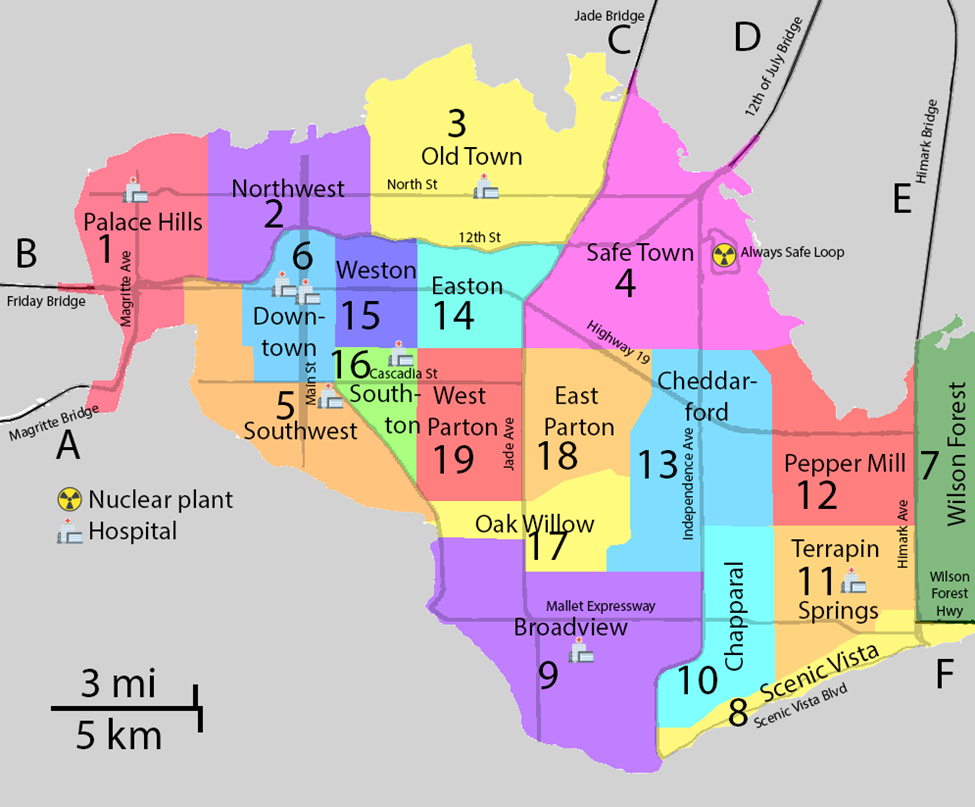

### В этих локациях присутствуют:

Город состоит из **19 районов**, каждый со своей критической инфраструктурой:

**🏥 Больницы**
* Palace Hills — Больница Химарк (хирургия, кардиология)
* Old Town — Больница Old Town (диабет, онкология, ортопедия)
* Downtown — Травматологическая больница + Детская больница
* Broadview — Общественная больница
* Terrapin Springs — Больница Goldcare
* Southton — Больница Eaglepeak (неврология, интенсивная терапия)
<br><br>

**⚛️ Атомная станция**
* Safe Town — АЭС "Always Safe" (72% городского электроснабжения)
<br><br>

**🌉 Мосты и шоссе (транспорт)**
* Мост Магритта — соединяет ? (нужно уточнить по карте)
* Мост Пятницы — соединяет ?
* Нефритовый мост — соединяет ?
* Мост 12 июля — соединяет ?
* Мост Химарк — соединяет ?
* Лесное шоссе Уилсона — идет через Wilson Forest
<br><br>

**🔥 Пожарные станции**
* По всему городу 34 станции, конкретное распределение не указано
<br><br>

**📡 Радиационные мониторы**

9 штук:
* 1 у входа на станцию (Safe Town)
* 8 по гzроду (где именно - не указано)
<br><br>

**🏫 Школы**
* Old Town — Old Town Unified School Division
* Broadview — Broadview Unified School Division
* Terrapin Springs — Terrapin Springs Unified School Division + Средняя школа Terrapin Springs (лучшая фермерская программа)
* Easton — Easton Unified School Division (хорошие школы)
* Parton — Parton Unified School Division (East Parton + West Parton)
<br><br>

**🎓 Университет**
* West Parton — Университет Сент-Химарк + Институт данных Alderwood
<br><br>

**🏛️ Музей**
* West Parton — Музей Святого Химарка
<br><br>

**🌳 Природные зоны**
* Wilson Forest — Природный заповедник Уилсон-Форест
* Palace Hills — Прибрежные парки
<br><br>

**🔧 Текущие ремонты (важно!)**
* Old Town — замена водопроводных сетей + модернизация электричества
* East Parton — ремонт водопровода (Блэр и Куили)
* West Parton — плановое обслуживание канализации
* Wilson Forest — ремонт обочин на шоссе (задержки)
* Broadview, Scenic Vista, Southton — ремонт жилых улиц
* Downtown — ремонт дорог и светофоров
* Chapparal, Cheddarford — ремонт дорог
* Магритта и Нефритовый мосты — ремонт настила (ограничения)

График показывающий ущерб 

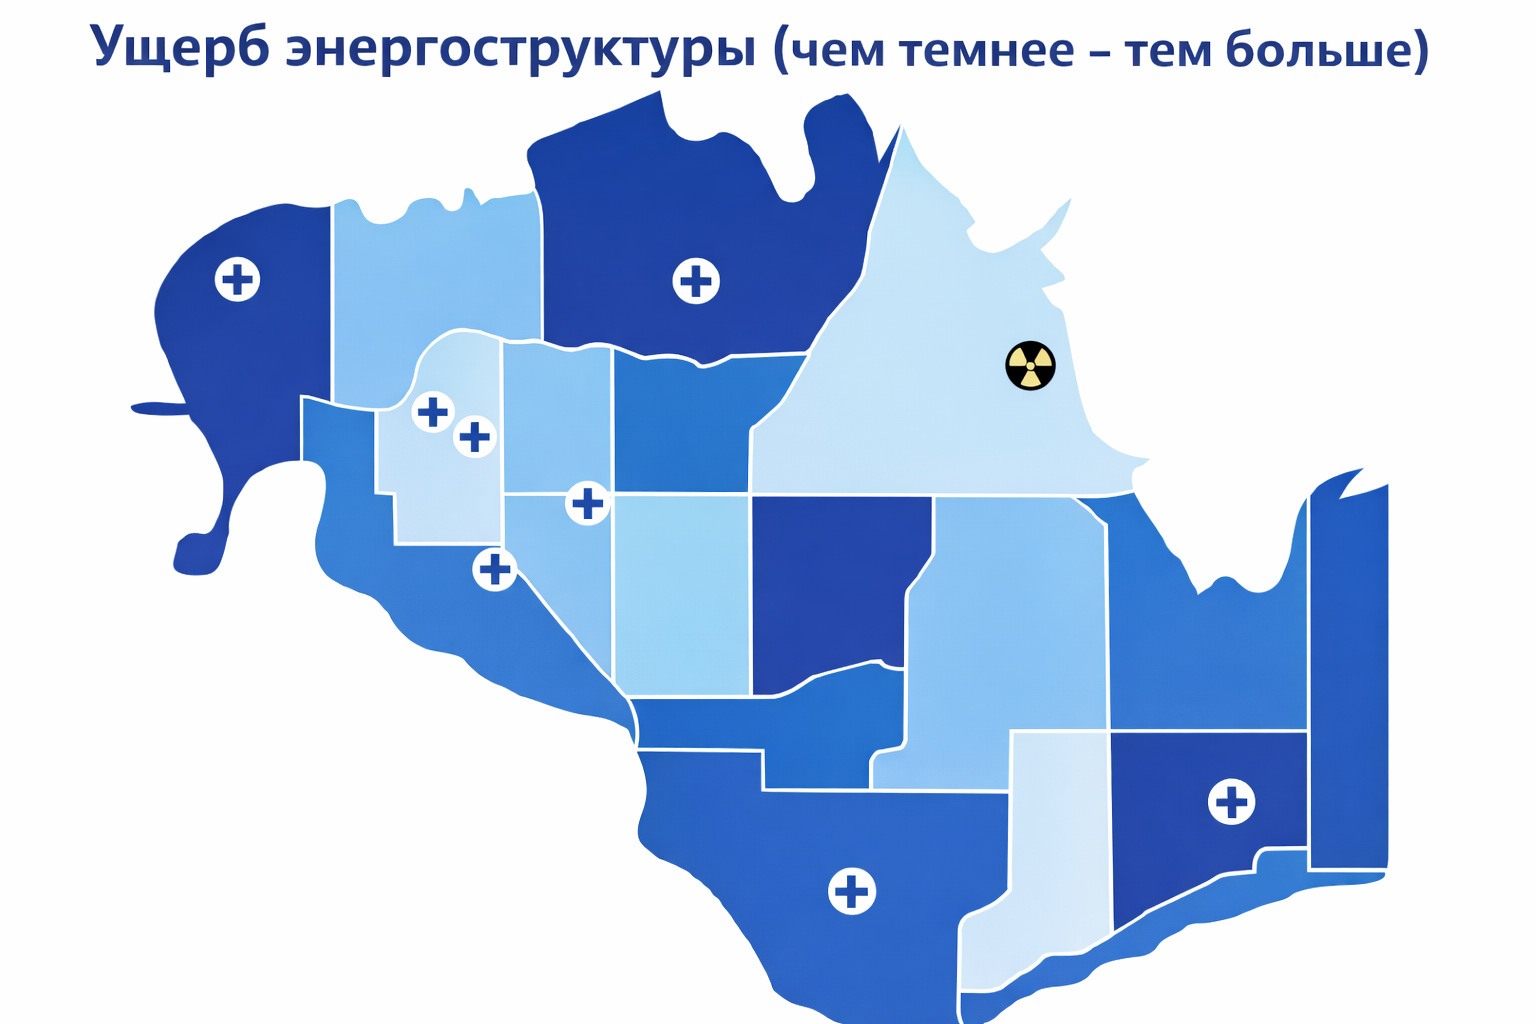

In [4]:
df.describe()

,sewer_and_water,power,roads_and_bridges,medical,buildings,shake_intensity,location
count,82899.000000,83070.000000,83070.000000,35629.000000,82900.000000,70926.000000,83070.000000
mean,5.649139,6.045371,5.743289,5.322687,4.744005,2.682641,8.978488
std,2.787791,2.851951,2.506399,2.527679,2.256358,1.935366,5.123608
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,1.000000
25%,3.000000,4.000000,4.000000,4.000000,3.000000,1.000000,4.000000
50%,6.000000,7.000000,6.000000,6.000000,5.000000,2.000000,8.000000
75%,8.000000,8.000000,7.000000,7.000000,6.000000,4.000000,14.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,19.000000


## Доп. изображения
Также нам даны, по условию, два изображения, которые дают понять, что было минимум два толчка. Один из которых слабее (как позде выяснится это форшок - удары до основного землятресения)

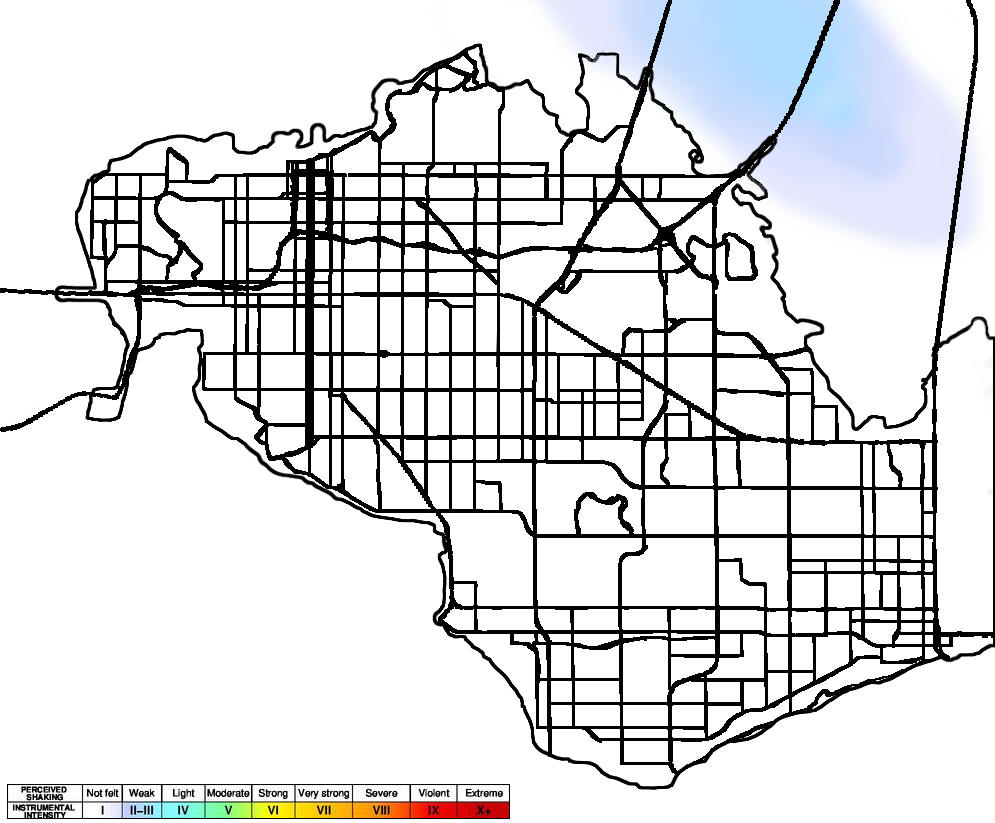

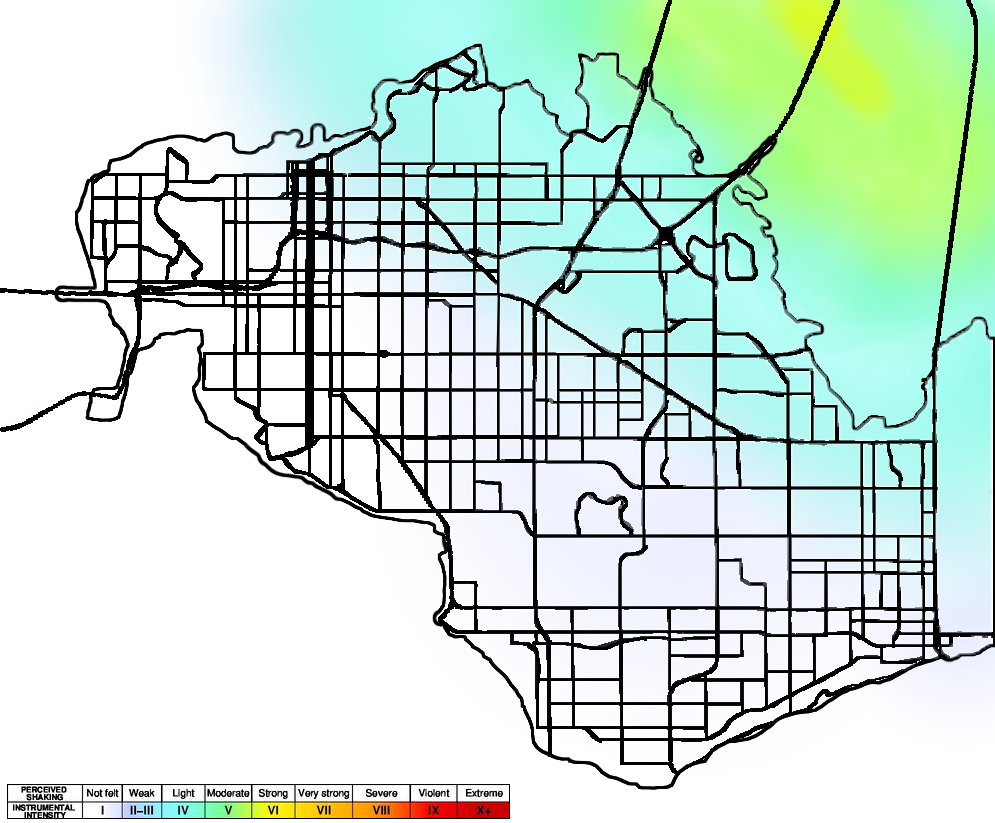

# 2. Обработка данных

In [5]:
print("Всего записей", len(df))
print(f"Период: {df['time'].min()} - {df['time'].max()}")

Всего записей 83070
Период: 2020-04-06 00:00:00 - 2020-04-11 00:00:00


In [6]:

df['time'] = pd.to_datetime(df['time'])

# Словарь районов
neighborhoods = {
    1: 'Palace Hills', 2: 'Northwest', 3: 'Old Town', 4: 'Safe Town',
    5: 'Southwest', 6: 'Downtown', 7: 'Wilson Forest', 8: 'Scenic Vista',
    9: 'Broadview', 10: 'Chapparal', 11: 'Terrapin Springs', 12: 'Pepper Mill',
    13: 'Cheddarford', 14: 'Easton', 15: 'Weston', 16: 'Southton',
    17: 'Oak Willow', 18: 'East Parton', 19: 'West Parton'
}

# Убедимся, что location имеет правильный тип для маппинга
df['neighborhood'] = df['location'].map(neighborhoods)
df['hour'] = df['time'].dt.hour
df['date'] = df['time'].dt.date
df['day_hour'] = df['time'].dt.strftime('%m-%d %H:00')

# Категории ущерба для удобства
damage_cols = ['shake_intensity', 'sewer_and_water', 'power', 
               'roads_and_bridges', 'medical', 'buildings']

print(f"Период данных: {df['time'].min()} — {df['time'].max()}")
print(f"Длительность: {(df['time'].max() - df['time'].min()).days} дней")
print(f"Всего отчётов: {len(df):,}")
print(f"Уникальных районов: {df['location'].nunique()}")
print(f"Уникальных временных меток: {df['time'].nunique()}")


Период данных: 2020-04-06 00:00:00 — 2020-04-11 00:00:00
Длительность: 5 дней
Всего отчётов: 83,070
Уникальных районов: 19
Уникальных временных меток: 1441


In [7]:
missing = df[damage_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Пропусков': missing,
    'Процент': missing_pct
}).sort_values('Процент', ascending=False)

print("Анализ пропущенных значений:")
print("="*40)
print(missing_df)

Анализ пропущенных значений:
                   Пропусков  Процент
medical                47441     57.1
shake_intensity        12144     14.6
sewer_and_water          171      0.2
buildings                170      0.2
power                      0      0.0
roads_and_bridges          0      0.0


In [8]:
# Для shake_intensity и др. столбцов пропуски можно заполнить средним по району, но лучше этого не делать для анализа неопределённости
# df['shake_intensity'] = df.groupby('location')['shake_intensity'].transform(lambda x: x.fillna(x.mean()))


**medical (57% пропусков)** — гражданская оценка медицинских учреждений **ненадёжна**. Большинство жителей физически не могут знать состояние больниц: они не работают там, не находятся на лечении. Люди видят разрушенное здание снаружи, но не понимают, функционирует ли операционная. **Вывод:** для оценки медицинской инфраструктуры необходимы прямые отчёты от больниц, краудсорсинг здесь неприменим.

**shake_intensity (15% пропусков)** - часть граждан сообщала только о видимых повреждениях, не оценивая саму тряску (возможно, заполняли отчёт постфактум, когда уже не помнили интенсивность).

**Методологическое решение:** пропуски НЕ заполняются средними/медианами. Отсутствие данных само по себе является информацией о неопределённости и должно учитываться при расчёте надёжности.

# 3. Анализ

In [9]:
reports_by_area = df.groupby('neighborhood').size().sort_values(ascending=False)
reports_by_area_pct = (reports_by_area / len(df) * 100).round(1)

report_summary = pd.DataFrame({
    'Отчётов': reports_by_area,
    '% от общего': reports_by_area_pct,
    'Кумулятивный %': reports_by_area_pct.cumsum()
})
print(report_summary)

# --- TREEMAP ---
treemap_df = pd.DataFrame({
    'neighborhood': reports_by_area.index,
    'count': reports_by_area.values,
    'pct': reports_by_area_pct.values
})
treemap_df['label'] = treemap_df.apply(
    lambda r: f"{r['neighborhood']}<br>{r['count']} ({r['pct']}%)", axis=1
)

fig = px.treemap(
    treemap_df,
    path=['neighborhood'],
    values='count',
    color='count',
    color_continuous_scale='RdYlGn',
    title='🏘️ Распределение отчётов по районам',
    custom_data=['pct']
)

fig.update_traces(
    textinfo='label+value+percent root',
    textfont=dict(size=14, family='Arial Black'),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Отчётов: %{value:,}<br>'
        'Доля: %{customdata[0]}%<br>'
        '<extra></extra>'
    ),
    marker=dict(cornerradius=5)
)

fig.update_layout(
    width=1100, height=650,
    font=dict(family='Segoe UI', size=13),
    title=dict(font=dict(size=20, family='Arial Black'), x=0.5),
    coloraxis_colorbar=dict(
        title='Кол-во<br>отчётов',
        thickness=15,
        len=0.6
    ),
    margin=dict(t=80, l=20, r=20, b=20)
)
fig.show()

                  Отчётов  % от общего  Кумулятивный %
neighborhood                                          
Scenic Vista        13889         16.7            16.7
Old Town            13535         16.3            33.0
Broadview            8796         10.6            43.6
Easton               6429          7.7            51.3
Northwest            5390          6.5            57.8
Weston               4729          5.7            63.5
East Parton          4545          5.5            69.0
Pepper Mill          3463          4.2            73.2
Downtown             3160          3.8            77.0
Southton             3145          3.8            80.8
Safe Town            2919          3.5            84.3
Terrapin Springs     2844          3.4            87.7
Chapparal            2213          2.7            90.4
Oak Willow           1727          2.1            92.5
Southwest            1710          2.1            94.6
Palace Hills         1662          2.0            96.6
West Parto

## 6. Территориальное распределение отчётов (Treemap)

**Treemap** визуализирует объём данных по районам через размер блоков — чем крупнее блок, тем больше отчётов.

### Ключевые паттерны:

**Топ-3 района (33% всех отчётов):**
1. **Scenic Vista** — 13 889 (16.7%) — максимальная активность граждан
2. **Old Town** — 13 535 (16.3%) — второй по объёму данных
3. **Broadview** — 8 796 (10.6%)

**Зона статистической ненадёжности (<3 000 отчётов, 7 районов):**
- Chapparal (2 213), Oak Willow (1 727), Southwest (1 710), Palace Hills (1 662), West Parton (1 515), Cheddarford (1 226), **Wilson Forest (173)**

### Критические наблюдения:

**Wilson Forest** — аномально низкая активность (0.2% отчётов). Это либо **малонаселённая зона**, либо **отключение связи** из-за удалённости. Любые средние для этого района **статистически недостоверны** (выборка <200 из 83 000).

**Safe Town** (2 919 отчётов, 11-е место) — парадоксально мало для района с АЭС, обеспечивающей 72% электроэнергии города. Возможные причины:
- Низкая плотность населения (санитарная зона вокруг реактора)
- Эвакуация после землетрясения
- **Риск:** отсутствие данных о критической инфраструктуре

### Методологическое замечание:

Количество отчётов **не равно** степени ущерба. Это косвенный индикатор **населения** и **доступности связи**. Количество отчётов — это индикатор операционной нагрузки, а не тяжести разрушений. Район с 14 000 отчётов требует огромных ресурсов для обработки обращений и распределения помощи, в то время как район с 200 отчётов может требовать приоритетной разведки, так как малое число данных может быть вызвано полным отсутствием связи.

**Цветовая шкала RdYlGn** от зелёного (много отчётов) к красному (мало отчётов) подчёркивает диспропорцию покрытия территории данными.

In [10]:


# Группировка и сглаживание
grouped = df.groupby(pd.Grouper(key='time', freq='1H')).agg({
    'shake_intensity': 'mean'
})
grouped['report_count'] = df.groupby(pd.Grouper(key='time', freq='1H')).size()
grouped = grouped.reset_index()

# Сглаживание (3-часовое окно)
grouped['shake_smooth'] = grouped['shake_intensity'].rolling(3, min_periods=1).mean()
grouped['reports_smooth'] = grouped['report_count'].rolling(3, min_periods=1).mean()

# 1. Количество отчётов - Area Chart с градиентом
fig_reports = go.Figure()
fig_reports.add_trace(
    go.Scatter(
        x=grouped['time'],
        y=grouped['reports_smooth'],
        name='Количество отчётов',
        fill='tozeroy',  # Заполнение до оси X
        fillcolor='rgba(74, 144, 226, 0.4)',
        line=dict(color='#4A90E2', width=2),
        mode='none',  # Убираем линию, оставляем только заливку
        hovertemplate='Время: %{x}<br>Отчёты: %{y:.1f}<extra></extra>'
    )
)
fig_reports.update_layout(
    title='Количество отчётов во времени (Area Chart)',
    template='plotly_white',
    width=1200,
    height=450,
    margin=dict(l=50, r=50, t=60, b=50)
)
fig_reports.update_yaxes(title_text='Количество отчётов')
fig_reports.update_xaxes(title_text='Время')
fig_reports.show()

# 2. Интенсивность тряски - Area Chart
fig_shake = go.Figure()
fig_shake.add_trace(
    go.Scatter(
        x=grouped['time'],
        y=grouped['shake_smooth'],
        name='Интенсивность тряски',
        fill='tozeroy',
        fillcolor='rgba(245, 166, 35, 0.4)',
        line=dict(color='#F5A623', width=2),
        mode='none',
        hovertemplate='Время: %{x}<br>Интенсивность: %{y:.2f}<extra></extra>'
    )
)
fig_shake.update_layout(
    title='Средняя интенсивность тряски (Area Chart)',
    template='plotly_white',
    width=1200,
    height=450,
    margin=dict(l=50, r=50, t=60, b=50)
)
fig_shake.update_yaxes(title_text='Интенсивность')
fig_shake.update_xaxes(title_text='Время')
fig_shake.show()

In [20]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import HBox, VBox

# ============================================================
# 1. Подготовка
# ============================================================

df = df.copy()
df['time'] = pd.to_datetime(df['time'])

categories = {
    'shake_intensity': 'Интенсивность сотрясения',
    'sewer_and_water': 'Канализация и водоснабжение',
    'power': 'Электроснабжение',
    'roads_and_bridges': 'Дороги и мосты',
    'medical': 'Медицина',
    'buildings': 'Здания'
}

colors = {
    'shake_intensity': '#e377c2',
    'sewer_and_water': '#1f77b4',
    'power': '#ff7f0e',
    'roads_and_bridges': '#2ca02c',
    'medical': '#d62728',
    'buildings': '#9467bd'
}

events = [
    ('2020-04-06 16:00:00', 'Форшок', 'orange'),
    ('2020-04-08 09:00:00', 'Толчок 1', 'red'),
    ('2020-04-09 15:00:00', 'Толчок 2', 'darkred')
]

# ============================================================
# 2. Функция агрегации
# ============================================================

def aggregate_metric(df, category, freq='1H'):
    tmp = df.copy()
    tmp['time_bin'] = tmp['time'].dt.floor(freq)

    def p90(x):
        x = x.dropna()
        return x.quantile(0.9) if len(x) > 0 else np.nan

    def share_ge_7(x):
        x = x.dropna()
        return (x >= 7).mean() if len(x) > 0 else np.nan

    def share_ge_8(x):
        x = x.dropna()
        return (x >= 8).mean() if len(x) > 0 else np.nan

    def high_damage_count(x):
        x = x.dropna()
        return (x >= 7).sum()

    grouped = tmp.groupby('time_bin')[category].agg(
        mean='mean',
        median='median',
        max='max',
        count='count',
        p90=p90,
        share_ge_7=share_ge_7,
        share_ge_8=share_ge_8,
        high_damage_count=high_damage_count
    ).reset_index()

    return grouped

# ============================================================
# 3. Output
# ============================================================

plot_output = widgets.Output()

# ============================================================
# 4. Виджеты
# ============================================================

category_checkboxes = []
for cat_key, cat_name in categories.items():
    checkbox = widgets.Checkbox(
        value=(cat_key != 'shake_intensity'),
        description=cat_name,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='260px')
    )
    category_checkboxes.append((cat_key, checkbox))

metric_dropdown = widgets.Dropdown(
    options=[
        ('Доля тяжёлых отчётов (>=7)', 'share_ge_7'),
        ('Доля очень тяжёлых отчётов (>=8)', 'share_ge_8'),
        ('90-й процентиль (p90)', 'p90'),
        ('Максимум (max)', 'max'),
        ('Среднее (mean)', 'mean'),
        ('Медиана (median)', 'median'),
        ('Число тяжёлых отчётов (>=7)', 'high_damage_count'),
        ('Количество непустых отчётов', 'count')
    ],
    value='share_ge_7',
    description='Метрика:',
    layout=widgets.Layout(width='420px')
)

freq_dropdown = widgets.Dropdown(
    options=[
        ('5 минут', '5min'),
        ('15 минут', '15min'),
        ('30 минут', '30min'),
        ('1 час', '1H'),
        ('2 часа', '2H')
    ],
    value='15min',
    description='Шаг:',
    layout=widgets.Layout(width='250px')
)

select_all_button = widgets.Button(
    description='Все',
    button_style='primary',
    layout=widgets.Layout(width='80px')
)

clear_all_button = widgets.Button(
    description='Очистить',
    layout=widgets.Layout(width='100px')
)

update_button = widgets.Button(
    description='Обновить график',
    button_style='success',
    layout=widgets.Layout(width='160px')
)

# ============================================================
# 5. Функция обновления
# ============================================================

def update_plot(selected_categories, selected_metric, selected_freq):
    with plot_output:
        plot_output.clear_output(wait=True)

        if not selected_categories:
            print("⚠️ Выберите хотя бы одну категорию.")
            return

        fig = go.Figure()

        y_max = 0

        for category in selected_categories:
            agg = aggregate_metric(df, category, freq=selected_freq)

            fig.add_trace(go.Scatter(
                x=agg['time_bin'],
                y=agg[selected_metric],
                name=categories[category],
                mode='lines',
                line=dict(color=colors[category], width=2),
                hovertemplate=(
                    f"<b>{categories[category]}</b><br>"
                    "Время: %{x|%Y-%m-%d %H:%M}<br>"
                    f"{selected_metric}: "+"%{y:.3f}<extra></extra>"
                )
            ))

            current_max = agg[selected_metric].max()
            if pd.notna(current_max):
                y_max = max(y_max, current_max)

        if y_max == 0 or pd.isna(y_max):
            y_max = 1
        else:
            y_max *= 1.15

        # Линии событий
        for event_time, event_name, event_color in events:
            fig.add_shape(
                type="line",
                x0=event_time, x1=event_time,
                y0=0, y1=y_max,
                xref='x', yref='y',
                line=dict(color=event_color, width=1.5, dash='dash')
            )
            fig.add_annotation(
                x=event_time,
                y=y_max,
                xref='x', yref='y',
                text=event_name,
                showarrow=False,
                font=dict(size=10, color=event_color),
                yshift=10,
                bgcolor='rgba(255,255,255,0.7)'
            )

        metric_titles = {
            'share_ge_7': 'Доля тяжёлых отчётов (>=7)',
            'share_ge_8': 'Доля очень тяжёлых отчётов (>=8)',
            'p90': '90-й процентиль',
            'max': 'Максимум',
            'mean': 'Среднее',
            'median': 'Медиана',
            'high_damage_count': 'Число тяжёлых отчётов (>=7)',
            'count': 'Количество непустых отчётов'
        }

        fig.update_layout(
            title=f'Динамика ущерба: {metric_titles[selected_metric]}',
            xaxis_title='Время',
            yaxis_title=metric_titles[selected_metric],
            hovermode='x unified',
            width=1250,
            height=650,
            legend=dict(
                orientation='h',
                yanchor='bottom',
                y=1.02,
                xanchor='right',
                x=1,
                bgcolor='rgba(255,255,255,0.8)'
            ),
            plot_bgcolor='white',
            xaxis=dict(
                showgrid=True,
                gridcolor='lightgray',
                gridwidth=0.5
            ),
            yaxis=dict(
                showgrid=True,
                gridcolor='lightgray',
                gridwidth=0.5
            ),
            margin=dict(l=60, r=30, t=90, b=60)
        )

        fig.show()

        
        if selected_metric == 'share_ge_7':
            print("Как интерпретировать:")
            print(" - Показывает долю отчётов с тяжёлым ущербом (оценка >= 7).")
            print(" - Это одна из лучших метрик для визуализации реального ущерба.")
        elif selected_metric == 'share_ge_8':
            print("Как интерпретировать:")
            print(" - Показывает долю отчётов с очень тяжёлым ущербом (оценка >= 8).")
        elif selected_metric == 'p90':
            print("Как интерпретировать:")
            print(" - Показывает уровень верхних 10% самых тяжёлых оценок.")
        elif selected_metric == 'max':
            print("Как интерпретировать:")
            print(" - Показывает экстремальные случаи, но может быть шумным.")
        elif selected_metric == 'high_damage_count':
            print("Как интерпретировать:")
            print(" - Показывает абсолютное число тяжёлых сообщений, что важно для масштаба проблемы.")
        elif selected_metric == 'count':
            print("Как интерпретировать:")
            print(" - Показывает объём данных, а не ущерб напрямую.")

# ============================================================
# 6. Обработчики
# ============================================================

def select_all(b):
    for _, checkbox in category_checkboxes:
        checkbox.value = True

def clear_all(b):
    for _, checkbox in category_checkboxes:
        checkbox.value = False

def on_update_clicked(b):
    selected = [cat_key for cat_key, checkbox in category_checkboxes if checkbox.value]
    update_plot(selected, metric_dropdown.value, freq_dropdown.value)

select_all_button.on_click(select_all)
clear_all_button.on_click(clear_all)
update_button.on_click(on_update_clicked)

# ============================================================
# 7. Интерфейс
# ============================================================

checkbox_grid = widgets.GridBox(
    children=[checkbox for _, checkbox in category_checkboxes],
    layout=widgets.Layout(
        grid_template_columns='repeat(3, 260px)',
        grid_gap='8px',
        padding='10px 0'
    )
)

title = widgets.HTML("""
<div style="background-color:#f0f0f0; padding:10px; border-radius:6px; margin-bottom:10px;">
    <h3 style="margin:0;">📊 Метрики реального ущерба</h3>
    <p style="margin:5px 0 0 0; color:gray; font-size:12px;">
        Вместо среднего используем более устойчивые метрики: долю тяжёлых отчётов, p90, максимум и число тяжёлых сообщений.
    </p>
</div>
""")

controls = VBox([
    title,
    HBox([metric_dropdown, freq_dropdown]),
    HBox([select_all_button, clear_all_button, update_button]),
    checkbox_grid
])

display(controls)
display(plot_output)

# Начальный график
default_selected = [cat_key for cat_key, checkbox in category_checkboxes if checkbox.value]
update_plot(default_selected, metric_dropdown.value, freq_dropdown.value)

Output()

## Многомерный анализ ущерба (Interactive Line Chart)

Реализован интерактивный виджет с возможностью **выборочного отображения** 6 категорий ущерба на едином графике. Используется **Line Chart** для отслеживания динамики каждой категории во времени.

### Цветовое кодирование категорий:

- 🩷 **shake_intensity** — интенсивность сотрясения
- 🔵 **sewer_and_water** — канализация и водоснабжение
- 🟠 **power** — электроснабжение
- 🟢 **roads_and_bridges** — дороги и мосты
- 🔴 **medical** — медицина
- 🟣 **buildings** — здание

### Функциональность:

- **Кнопки "Все"/"Очистить"** — быстрый выбор/сброс категорий
- **Чекбоксы** — индивидуальный контроль каждой переменной
- **Hover tooltips** — точные значения при наведении
- **Вертикальные маркеры** — отметки времён землетрясений (форшок, толчки 1 и 2)

Для анализа использованы временные графики, показывающие **количество отчётов**, **интенсивность сотрясения** и **оценки по категориям инфраструктуры** в нескольких метриках — не только среднее, но и более устойчивые показатели, включая **долю тяжёлых отчётов**, **верхние перцентили** и **локальные пики**. Поэтому интерпретация строится не вокруг одного среднего значения, а вокруг **общего поведения распределения оценок во времени**.

В нормальном состоянии, до крупных событий, почти все инфраструктурные категории удерживаются около **базового фонового уровня**, который визуально находится **примерно в районе 5 баллов**. Это не означает, что город “повреждён на 5 из 10”, а скорее отражает **типичный уровень пользовательских оценок в стабильный период**. Важнее то, что во время сейсмических событий этот режим **резко нарушается**: показатели по категориям **сначала проседают**, затем **начинают возвращаться** к привычному диапазону, а после этого становятся более **рваными и нестабильными**. Таким образом, сами землетрясения проявляются не столько как простой рост значений, сколько как **сильное отклонение всей структуры отчётов от обычного состояния**.

Первое заметное событие — **форшок 6 апреля около 16:00**. В этот момент наблюдается **небольшой всплеск активности** при ещё относительно низкой интенсивности тряски. Одновременно по большинству инфраструктурных категорий заметно **снижение значений относительно фонового уровня**. Это важно: слабое землетрясение здесь не выглядит как резкий рост тяжёлого ущерба, а скорее как **сбой привычного паттерна отчётности**. Вероятнее всего, в этот момент в систему начинает поступать много сообщений о **лёгких или умеренных последствиях**, из-за чего центральные метрики проседают, хотя по более чувствительным показателям всё равно видно, что ситуация изменилась. То есть форшок фиксируется не как “массовое разрушение”, а как **локальное и раннее нарушение стабильности данных**.

Далее происходит **первый крупный толчок 8 апреля около 09:00**. Здесь уже виден **резкий скачок интенсивности сотрясения** и **сильный рост числа отчётов**. В этот момент почти все категории снова меняют поведение: сначала оценки проседают, а затем постепенно начинают восстанавливаться. Но если смотреть не только на центральные значения, а на **долю тяжёлых сообщений**, **p90** и **локальные экстремумы**, становится видно, что одновременно с этим в данных появляется **тяжёлый хвост распределения** — то есть всё больше сообщений относится к реально серьёзным повреждениям. Иными словами, **средние или медианные значения сами по себе не отражают всей тяжести события**, зато другие метрики показывают, что именно после **Толчка №1** начинается фаза **реального системного ущерба**.

Именно после **Толчка №1** особенно хорошо заметны **зубчатые пики** — короткие резкие всплески на графиках. Это один из самых важных паттернов во всей временной динамике. Такие пики логично интерпретировать как **пакетную отправку отчётов после временного отсутствия связи или электричества**. То есть в периоды отключения сообщения не поступают равномерно, а затем, после частичного восстановления энергоснабжения, загружаются сразу группой. Поэтому эти “иглы” на графике означают не обязательно новые разрушения в конкретную минуту, а то, что **данные начали поступать с задержкой и кусками**. Этот эффект особенно важен для правильной интерпретации последствий землетрясения: **нестабильность графика отражает не только ущерб, но и сбои в системе передачи информации**.

Следующий крупный этап — **второй толчок 9 апреля около 15:00**. Он снова сопровождается **всплеском тряски**, **изменением структуры отчётов** и новой фазой нестабильности. После него графики становятся ещё более рваными, а по некоторым категориям, прежде всего по **электроснабжению**, аномалии выглядят наиболее выраженно. Это указывает на то, что **повреждение электросети не только усиливает сам кризис, но и искажает данные**, потому что районы начинают временно исчезать из потока сообщений, а затем возвращаться в виде накопленных пакетов отчётов. Если после первого толчка это выглядело как заметный эффект, то после второго — уже как **системный сбой наблюдаемости**.

Дополнительным подтверждением этого служат повторяющиеся **резкие “колышки”** на временных графиках. Они говорят о том, что отчёты поступают **неравномерно**, а значит временная динамика отражает не только реальное изменение ущерба, но и **доступность канала связи**. Особенно важно, что такие пики появляются **после периодов провала или просадки**, что хорошо согласуется с гипотезой о временных отключениях света и последующей пакетной передаче накопленных сообщений.

Отдельный этап можно охарактеризовать как **частичную нормализацию 10 апреля около 12:00**. В этот момент наблюдается очередной сильный всплеск, который по характеру больше похож не на новое разрушительное событие, а на **восстановление способности отправлять данные**. Вероятнее всего, в этот момент часть районов получила обратно доступ к электричеству и связи, из-за чего накопленные за период отключения отчёты начали массово поступать в систему. Поэтому данный пик следует понимать не как новый основной удар, а как **эффект восстановления информационного потока**.

В целом картина выглядит так: до землетрясений существует **относительно стабильный фоновый уровень оценок**, во время событий этот режим **ломается**, затем значения по категориям **сначала снижаются**, после чего **возвращаются к базовому диапазону**, а поверх этого возникают **зубчатые пики**, связанные с **задержанной пакетной отправкой отчётов**. При этом для понимания ущерба недостаточно смотреть только на центральные метрики; гораздо важнее учитывать **тяжёлые хвосты распределения**, **долю сильных сообщений**, **верхние перцентили** и **локальные экстремумы**, потому что именно они лучше показывают реальные кризисные фазы.

Ключевой вывод состоит в том, что **электросеть — один из самых уязвимых элементов всей городской системы**. Её повреждение влияет не только на жизнь города, но и на саму возможность наблюдать кризис в реальном времени. Когда электричество и связь нестабильны, данные начинают поступать **рывками**, и поэтому любые провалы и последующие пики нужно трактовать не только как изменение ущерба, но и как **индикатор деградации самой системы отчётности**. Именно поэтому после **Толчка №1** и особенно после **Толчка №2** временные графики становятся не просто шумными, а **структурно ломанными**, что само по себе является важным симптомом кризиса.

In [12]:
# Если столбца neighborhood ещё нет — создаём
neighborhoods = {
    1: 'Palace Hills',
    2: 'Northwest',
    3: 'Old Town',
    4: 'Safe Town',
    5: 'Southwest',
    6: 'Downtown',
    7: 'Wilson Forest',
    8: 'Scenic Vista',
    9: 'Broadview',
    10: 'Chapparal',
    11: 'Terrapin Springs',
    12: 'Pepper Mill',
    13: 'Cheddarford',
    14: 'Easton',
    15: 'Weston',
    16: 'Southton',
    17: 'Oak Willow',
    18: 'East Parton',
    19: 'West Parton'
}

df['neighborhood'] = df['location'].map(neighborhoods)

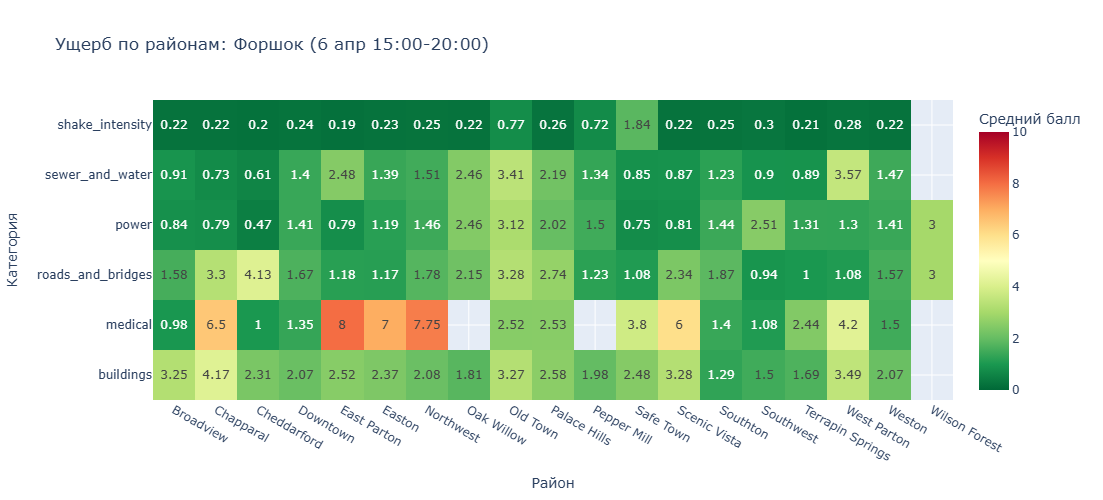

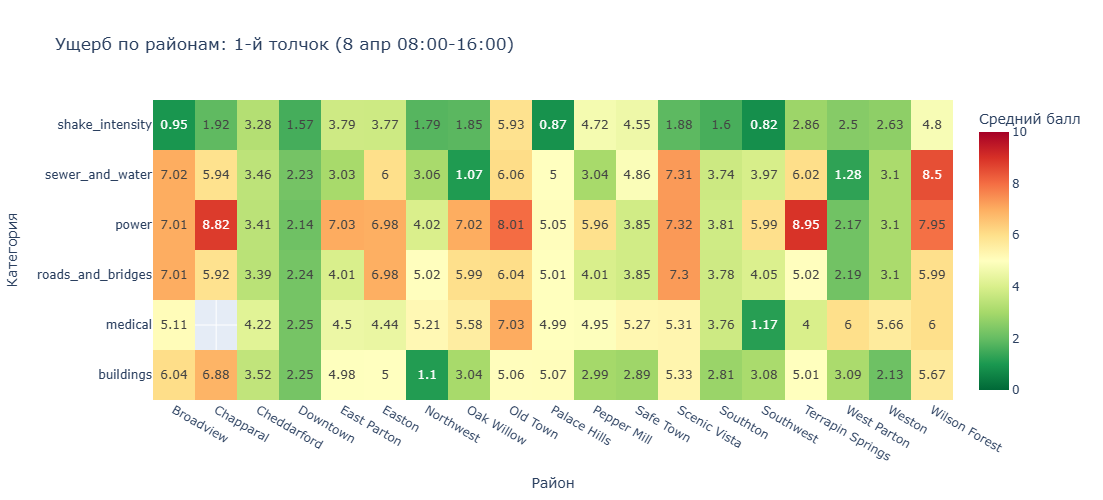

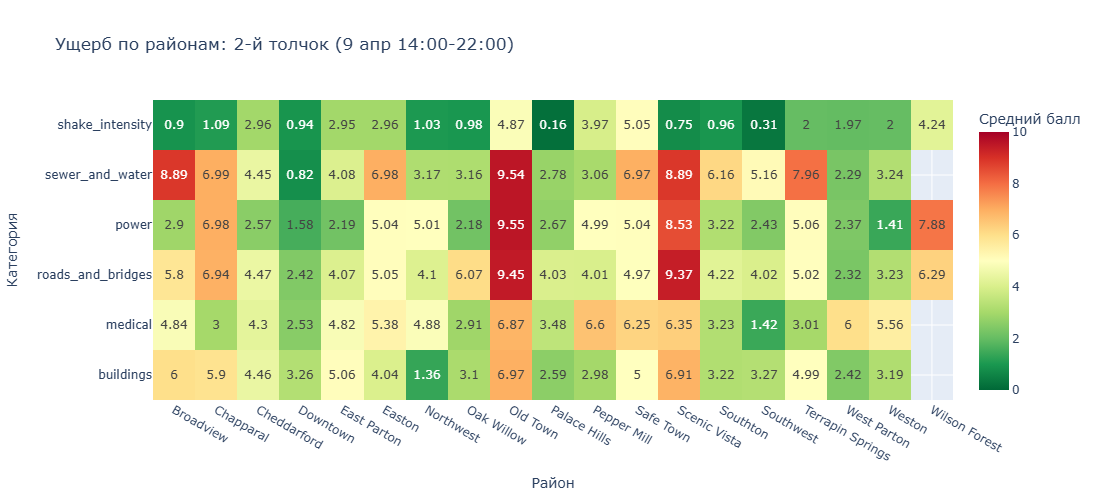

In [13]:
# ТЕПЛОВЫЕ КАРТЫ ДЛЯ КАЖДОГО ЗЕМЛЕТРЯСЕНИЯ ОТДЕЛЬНО
periods = {
    'Форшок (6 апр 15:00-20:00)': ('2020-04-06 15:00', '2020-04-06 20:00'),
    '1-й толчок (8 апр 08:00-16:00)': ('2020-04-08 08:00', '2020-04-08 16:00'),
    '2-й толчок (9 апр 14:00-22:00)': ('2020-04-09 14:00', '2020-04-09 22:00'),
}

damage_cols = ['shake_intensity', 'sewer_and_water', 'power', 
               'roads_and_bridges', 'medical', 'buildings']

for period_name, (start, end) in periods.items():
    period_data = df[(df['time'] >= start) & (df['time'] <= end)]
    
    heatmap_data = period_data.groupby('neighborhood')[damage_cols].mean().round(2)
    
    fig = px.imshow(
        heatmap_data.T,
        text_auto=True,
        aspect="auto",
        color_continuous_scale='RdYlGn_r',
        title=f'Ущерб по районам: {period_name}',
        labels=dict(x='Район', y='Категория', color='Средний балл'),
        zmin=0, zmax=10
    )
    fig.update_layout(width=1100, height=500)
    fig.show()

## Пространственное распределение ущерба (Heatmaps по событиям)

Для анализа построены **три отдельные тепловые карты**, каждая из которых показывает **средние значения пользовательских оценок по районам и категориям** в окрестности одного из трёх ключевых событий. Используется шкала **RdYlGn_r**:  
**зелёный** — низкие значения,  
**жёлтый** — умеренные,  
**красный** — высокие.  

Важно учитывать, что эти карты отражают **средние reported values**, то есть усреднённые пользовательские оценки, а не прямое инструментальное измерение физического ущерба. Поэтому их следует интерпретировать как **картину восприятия и фиксации последствий по районам**.

---

### **Форшок (6 апреля, 15:00–20:00)**

На карте форшока видно, что **интенсивность сотрясения остаётся низкой почти во всех районах** — в большинстве случаев около **0.2–0.3**, и только в отдельных районах немного выше. Наиболее заметное выделение по `shake_intensity` видно в **Pepper Mill (1.84)** и в меньшей степени в **Old Town (0.77)**, но в целом это действительно **слабое событие**.

При этом по отдельным инфраструктурным категориям наблюдаются **локальные повышенные значения**, которые не сопровождаются столь же высоким уровнем тряски. Например:

- **Old Town** — повышенные оценки по `sewer_and_water` (3.41), `power` (3.12), `roads_and_bridges` (3.28), `buildings` (3.27)
- **Easton** — высокие значения по `medical` (8.0) и заметные по другим категориям
- **Northwest** — `medical` 7.75
- **Chapparal** — `medical` 6.5
- **Southton** — `medical` 6.0

Это означает, что **форшок не выглядит как масштабное разрушительное событие**, но уже сопровождается **локальными аномалиями в отдельных категориях**. Особенно заметно, что категория **medical** в ряде районов имеет высокие значения даже при слабой тряске. Это может означать либо **локальную чувствительность медицинской инфраструктуры**, либо особенности пользовательской отчётности, когда в момент тревоги жители активнее сообщают о проблемах, не обязательно напрямую вызванных самим слабым толчком.

Главный вывод по форшоку:  
**пространственно это слабое и неравномерное событие**, при котором сильных массовых разрушений ещё не видно, но уже возникают **локальные проблемные точки**, особенно в отдельных инфраструктурных секторах.

---

### **Первый толчок (8 апреля, 08:00–16:00)**

На карте первого крупного толчка уже видно **массовое распространение ущерба по городу**. В отличие от форшока, здесь высокие значения появляются **сразу по нескольким категориям и во многих районах одновременно**.

По `shake_intensity` наиболее высокие значения видны в:
- **Old Town (5.93)** — самый выраженный центр сильной тряски
- **Pepper Mill (4.72)**
- **Wilson Forest (4.8)**
- **East Parton (3.79)**
- **Cheddarford (3.28)**

Наиболее тяжёлые инфраструктурные повреждения наблюдаются в следующих районах:

- **Chapparal**
  - `power` 8.82
- **Safe Town**
  - `power` 8.95
- **Wilson Forest**
  - `sewer_and_water` 8.5
  - `power` 7.95
- **Old Town**
  - `power` 8.01
  - `medical` 7.03
  - `sewer_and_water` 6.06
  - `roads_and_bridges` 6.04
- **Broadview**
  - `sewer_and_water` 7.02
  - `power` 7.01
  - `roads_and_bridges` 7.01
  - `buildings` 6.04
- **Easton**
  - `power` 7.03
- **Scenic Vista**
  - `sewer_and_water` 7.31
  - `power` 7.32
  - `roads_and_bridges` 7.3

Здесь особенно важно, что **ущерб уже не ограничивается одной категорией**, а становится **многосекторным**: одновременно страдают вода, электричество, дороги, здания и местами медицинская инфраструктура.  

При этом зависимость между `shake_intensity` и ущербом видна **не идеально линейная**. Некоторые районы показывают **очень высокий ущерб при умеренной тряске**, а некоторые — наоборот, не самые экстремальные значения по инфраструктуре при заметной тряске. Это означает, что на последствия влияют не только сила сотрясения, но и **локальная уязвимость района**, состояние застройки и, возможно, накопленный эффект после предыдущих нарушений.

Главный вывод по первому толчку:  
**это уже полноценное широкомасштабное кризисное событие**, при котором особенно сильно выделяются **Old Town, Broadview, Scenic Vista, Safe Town, Chapparal и Wilson Forest**.

---

### **Второй толчок (9 апреля, 14:00–22:00)**

Карта второго толчка показывает, что ситуация становится ещё более тяжёлой и в ряде районов **ущерб усиливается по нескольким категориям одновременно**. По `shake_intensity` максимальные значения уже не такие экстремальные, как в первом событии, но инфраструктурные оценки в ряде районов оказываются **ещё выше**, что указывает на **накопление последствий**.

Наиболее заметные районы:

- **Old Town**
  - `sewer_and_water` 9.54
  - `power` 9.55
  - `roads_and_bridges` 9.45
  - `medical` 6.87
  - `buildings` 6.97

- **Safe Town**
  - `roads_and_bridges` 9.37
  - `power` 8.53
  - `sewer_and_water` 8.89
  - `medical` 6.35
  - `buildings` 6.91

- **Broadview**
  - `sewer_and_water` 8.89
  - `buildings` 6.0

- **Scenic Vista**
  - `sewer_and_water` 8.89

- **Terrapin Springs**
  - `sewer_and_water` 7.96

- **Wilson Forest**
  - `power` 7.88
  - `roads_and_bridges` 6.29

- **Southton**
  - `sewer_and_water` 6.16
  - `medical` 3.23

Во втором событии особенно хорошо видно, что **Old Town становится главным очагом системного кризиса**: у него почти по всем категориям значения приближаются к верхнему краю шкалы. Также резко выделяется **Safe Town**, что критично не только из-за высоких оценок, но и из-за стратегической значимости района.  

Важно и то, что ряд районов, например **Scenic Vista**, показывает высокие значения по отдельным категориям даже без экстремального `shake_intensity`. Это подтверждает, что ко второму толчку система уже работает в режиме **накопленного повреждения**, где новые последствия наслаиваются на старые.

Главный вывод по второму толчку:  
**ущерб становится более концентрированным и одновременно более тяжёлым**, а районы **Old Town** и **Safe Town** превращаются в критические точки, требующие первоочередного внимания.

---

## Общий вывод по heatmap-анализу

Тепловые карты показывают чёткую эволюцию кризиса:

- **форшок** — слабое и локальное событие с отдельными аномалиями;
- **первый толчок** — переход к широкомасштабным многокатегорийным повреждениям;
- **второй толчок** — усиление и накопление ущерба, особенно в стратегически важных районах.

Особенно важно, что по heatmaps видно:  
**высокий ущерб не всегда строго совпадает с максимальной тряской**. Это значит, что для принятия решений недостаточно смотреть только на `shake_intensity`; необходимо учитывать **реальные инфраструктурные оценки по категориям**, поскольку именно они показывают, где последствия уже стали критическими.


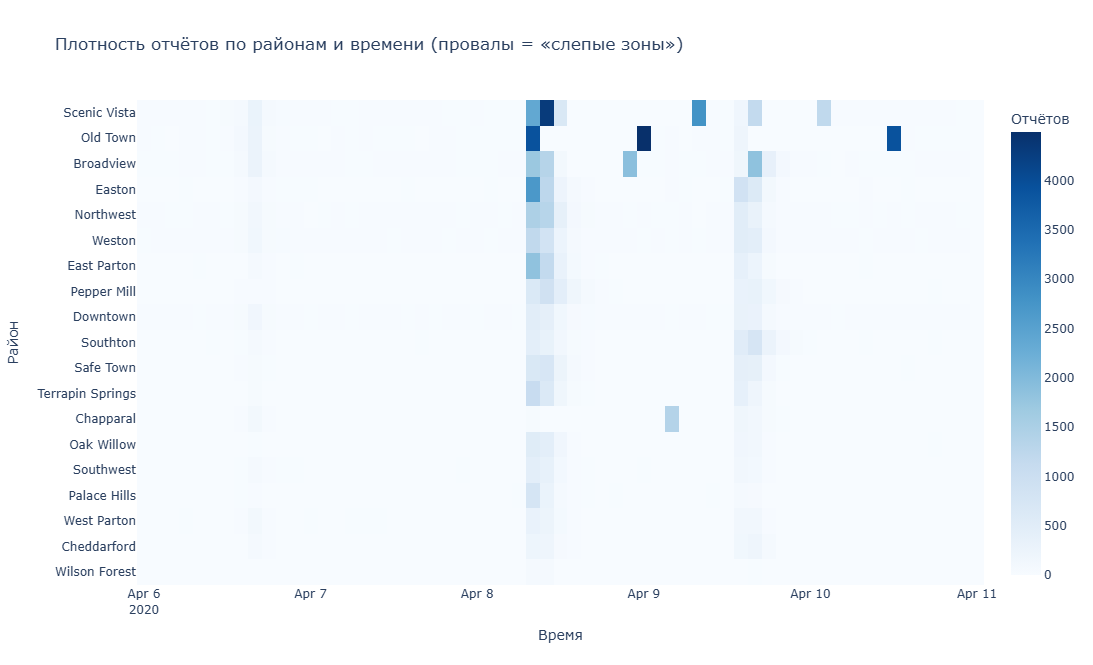

In [21]:
# Heatmap: количество отчётов по району и 2-часовому окну
reports_heatmap = df.groupby(
    [pd.Grouper(key='time', freq='2H'), 'neighborhood']
).size().unstack(fill_value=0)

# Сортируем районы по общему количеству отчётов
col_order = reports_by_area.index.tolist()
reports_heatmap = reports_heatmap[col_order]

fig = px.imshow(
    reports_heatmap.T,
    aspect="auto",
    color_continuous_scale='Blues',
    title='Плотность отчётов по районам и времени (провалы = «слепые зоны»)',
    labels=dict(x='Время', y='Район', color='Отчётов')
)

fig.update_layout(width=1200, height=650)
fig.show()

### "Слепые зоны" — молчание ≠ благополучие

На тепловой карте плотности видны **провалы** — периоды, когда из района 
перестают приходить отчёты. Это **критически важное наблюдение**:

**Отсутствие отчётов может означать:**
- ✅ В районе всё хорошо, не о чем сообщать
- ❌ Отключено электричество → телефоны разряжены → невозможно отправить отчёт
- ❌ Повреждена сотовая связь
- ❌ Люди эвакуировались

Самый яркий пример: **Old Town после второго толчка** (9 апреля, 15:00). 
Район, который стабильно давал 16% всех отчётов, **внезапно замолкает**. 
Последние отчёты перед молчанием показывали **высокий ущерб**. 
Это значит, что реальная ситуация в Old Town после второго толчка 
**хуже, чем показывают данные**, потому что данных просто нет.

**Вывод для спасателей:** в районы, которые «замолчали» после толчка, 
нужно **обязательно отправлять разведывательные бригады**. 
Молчание — это красный флаг, а не зелёный.

## Детальный анализ ключевых районов

### Old Town — эпицентр катастрофы
- Максимальная тряска при обоих крупных толчках
- Все категории ущерба достигают 7–9 баллов
- **После второго толчка — полное молчание** (отключение)
- Отягчающий фактор: шёл ремонт водопровода и электросетей
- Историческая кирпичная кладка — хрупкая при землетрясениях

### Scenic Vista — непропорциональный ущерб
- Тряска умеренная (5–6), но ущерб зданиям и инфраструктуре высокий (6–8)
- Самый «населённый» район (16.7% отчётов)
- Возможные причины: холм + крупные здания + элитная застройка

### Safe Town — стратегический приоритет
- Тряска и ущерб умеренные, но **здесь находится АЭС**
- Любые повреждения электро- и водоснабжения критичны 
  (система охлаждения реактора!)
- Приоритет НЕ по уровню ущерба, а по уровню ПОСЛЕДСТВИЙ

### Broadview — массовый ущерб
- 3-й по населению район
- Стабильно высокие показатели ущерба после обоих толчков
- Шёл ремонт жилых улиц (ослабленная дорожная инфраструктура)

### Downtown — медицинский узел
- Ущерб средний, но здесь расположены **Травматологическая** 
  и **Детская** больницы
- Шёл ремонт дорог и светофоров — затруднён подвоз пациентов
- Приоритет из-за критической инфраструктуры

### Chapparal — «слепая зона»
- Мало отчётов (2.7%) + провалы в данных
- Невозможно точно оценить ситуацию
- Нужна разведка на месте

In [15]:
# Std по районам — разброс оценок
uncertainty_by_area = df.groupby('neighborhood')[damage_cols].std().round(2)

# Сортируем по среднему std
uncertainty_by_area['mean_std'] = uncertainty_by_area.mean(axis=1)
uncertainty_by_area = uncertainty_by_area.sort_values('mean_std', ascending=False)
uncertainty_by_area = uncertainty_by_area.drop('mean_std', axis=1)

fig = px.imshow(
    uncertainty_by_area,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='YlOrRd',
    title='Стандартное отклонение оценок по районам (мера разногласия жителей)',
    labels=dict(x='Категория', y='Район', color='Std')
)
fig.update_layout(width=1000, height=650)
fig.show()

## Согласованность оценок граждан (Heatmap стандартных отклонений)

**Heatmap std** показывает **разброс** оценок внутри каждого района. Используется шкала **YlOrRd** (жёлтый-оранжевый-красный): красный = большой разброс = низкая согласованность.

### Наименее надёжные данные (красные ячейки):

**Palace Hills:**
- **power** std = 3.83 — **максимум на карте**
- buildings std = 3.25
- **Интерпретация:** электричество работает на одних улицах и отключено на других, граждане видят совершенно разную картину

**Downtown:**
- sewer_and_water std = 3.08, medical std = 2.85
- Большой район с неоднородной застройкой

**Old Town:**
- Удивительно **низкий** std (1.84) при **высоком** ущербе
- **Объяснение:** все согласны, что "всё плохо" — нет разногласий

### Наиболее надёжные данные (жёлтые ячейки):

**Scenic Vista:**
- Std от 0.77 до 2.03 + 13 889 отчётов
- **Золотой стандарт:** большая выборка + высокая согласованность

**Wilson Forest:**
- Низкий std (0.46-1.65), НО 173 отчёта
- **Ловушка:** "согласие" достигнуто просто потому, что писали одни и те же 10 человек

### Паттерны по категориям:

**shake_intensity** — std <2 почти везде (люди одинаково **чувствуют** тряску)
**power** — самый высокий разброс (электричество может быть включено на соседней улице и выключено на вашей)
**medical** — низкий std, но это артефакт 57% нулей (пропусков)

In [16]:
reliability = pd.DataFrame(index=df['neighborhood'].unique())

# 1. Количество отчётов (нормализованное)
report_counts = df.groupby('neighborhood').size()
reliability['n_reports'] = report_counts
reliability['n_score'] = (report_counts / report_counts.max() * 100).round(1)

# 2. Средний std (инвертированный — низкий std = высокая согласованность)
mean_std = df.groupby('neighborhood')[damage_cols].std().mean(axis=1)
reliability['mean_std'] = mean_std.round(2)
reliability['consistency_score'] = ((1 - mean_std / mean_std.max()) * 100).round(1)

# 3. Полнота данных (инвертированный % пропусков)
total_missing = df.groupby('neighborhood')[damage_cols].apply(
    lambda x: x.isna().sum().sum() / (len(x) * len(damage_cols)) * 100
)
reliability['missing_pct'] = total_missing.round(1)
reliability['completeness_score'] = (100 - total_missing).round(1)

# Итоговый индекс (среднее трёх компонент)
reliability['reliability_index'] = (
    (reliability['n_score'] + reliability['consistency_score'] + 
     reliability['completeness_score']) / 3
).round(1)

reliability = reliability.sort_values('reliability_index', ascending=False)

# Визуализация компонент
fig = go.Figure()

fig.add_trace(go.Bar(name='Объём данных', x=reliability.index, 
                     y=reliability['n_score'], marker_color='steelblue'))
fig.add_trace(go.Bar(name='Согласованность', x=reliability.index, 
                     y=reliability['consistency_score'], marker_color='seagreen'))
fig.add_trace(go.Bar(name='Полнота', x=reliability.index, 
                     y=reliability['completeness_score'], marker_color='coral'))

fig.add_trace(go.Scatter(
    x=reliability.index, y=reliability['reliability_index'],
    mode='lines+markers', name='Индекс надёжности',
    line=dict(color='black', width=3), marker=dict(size=8)
))

fig.update_layout(
    barmode='group',
    title='Индекс надёжности отчётов: три компоненты',
    width=1200, height=600,
    xaxis_tickangle=-45,
    yaxis_title='Баллы (0–100)',
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

# Таблица
print("\nРейтинг надёжности районов:")
print("="*80)
print(reliability[['n_reports', 'mean_std', 'missing_pct', 'reliability_index']].to_string())


Рейтинг надёжности районов:
                  n_reports  mean_std  missing_pct  reliability_index
Old Town              13535      1.84          0.9               75.1
Scenic Vista          13889      1.91         17.5               69.5
Broadview              8796      1.94          1.6               62.2
Terrapin Springs       2844      1.53          1.1               53.3
Easton                 6429      1.78         17.6               53.3
East Parton            4545      1.83         17.7               48.0
Pepper Mill            3463      1.72         17.6               46.9
Northwest              5390      2.09         19.4               46.1
Southton               3145      1.98         11.5               44.9
Southwest              1710      2.04          3.6               43.3
Safe Town              2919      1.97         17.7               42.3
Weston                 4729      2.31         20.2               41.5
Chapparal              2213      2.07         18.5           

## 10. Надёжность отчётов по районам

Построил комплексный индекс надёжности из трёх компонент:

1. **Объём данных** — больше отчётов → статистически надёжнее
2. **Согласованность** — низкий разброс оценок → жители согласны друг с другом
3. **Полнота** — мало пропусков → данные репрезентативны

### Наиболее надёжные районы:
- **Scenic Vista** — максимум отчётов + хорошая полнота
- **Old Town** — второй по объёму данных (но с оговоркой: 
  после 2-го толчка данных нет)
- **Broadview** — третий по объёму + достаточная согласованность
- **Easton** — стабильные, согласованные данные

### Наименее надёжные:
- **Wilson Forest** — 173 отчёта за 5 дней. При 19 районах 
  и 83 000 отчётов это **статистический шум**. Любые выводы 
  по Wilson Forest ненадёжны.
- **Cheddarford** — мало данных (1 226 отчётов), хотя землятресение рядом
- **West Parton** — мало данных + неполнота

### Категория `medical` — ненадёжна ВЕЗДЕ:
57% пропусков по всему городу. Граждане, видимо, не могут 
оценить состояние больниц. Для оценки медицинской ситуации 
нужны **данные от самих больниц**, а не краудсорсинг.

In [17]:
# Скользящее std по часам
hourly_std = df.set_index('time').resample('1H')[damage_cols].std().mean(axis=1).reset_index(name='mean_std')
hourly_count = df.set_index('time').resample('1H').size().reset_index(name='count')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=hourly_std['time'], y=hourly_std['mean_std'],
               name='Средний Std (разброс оценок)', 
               line=dict(color='red', width=2.5)),
    secondary_y=False
)

fig.add_trace(
    go.Bar(x=hourly_count['time'], y=hourly_count['count'],
           name='Количество отчётов', marker_color='blue', opacity=0.4),
    secondary_y=True
)

fig.add_vline(x='2020-04-06 16:00', line_dash="dot", line_color="gray")
fig.add_vline(x='2020-04-08 09:00', line_dash="dot", line_color="gray")
fig.add_vline(x='2020-04-09 15:00', line_dash="dot", line_color="gray")

fig.update_layout(
    title='Неопределённость данных во времени: разброс оценок vs объём данных',
    width=1200, height=550
)
fig.update_yaxes(title_text="Стандартное отклонение", secondary_y=False)
fig.update_yaxes(title_text="Количество отчётов", secondary_y=True)
fig.show()

## Как неопределённость меняется во времени

### Ключевые наблюдения:

**До землетрясений (6–8 апреля, до 09:00):**
- Мало отчётов → среднее ненадёжно (мало данных)
- НО: разброс оценок низкий → те немногие, кто отвечает, согласны

**Сразу после толчков:**
- Резкий всплеск отчётов → средние становятся надёжнее
- НО: разброс оценок ТОЖЕ растёт! Люди в шоке, оценивают по-разному
- Это парадокс: данных больше, но они противоречивее

**Через несколько часов после толчка:**
- Отчёты продолжают приходить, разброс снижается
- Люди успокаиваются, оценки становятся более объективными
- Это **наиболее надёжный период** для принятия решений

**После отключений электричества:**
- Отчёты прекращаются → **неопределённость максимальна** 
  (мы ничего не знаем)
- Это хуже, чем противоречивые данные — это ОТСУТСТВИЕ данных

### Вывод:
Оптимальное окно для принятия решений — **2–6 часов после толчка**: 
достаточно данных + оценки стабилизировались. 
Немедленные решения (первые 30 минут) неизбежно основаны 
на ненадёжных данных.

In [18]:
overall_damage = df.groupby('neighborhood')[damage_cols].mean().round(2)
overall_damage['composite'] = overall_damage.mean(axis=1).round(2)
overall_damage = overall_damage.sort_values('composite', ascending=False)

fig = px.imshow(
    overall_damage,
    text_auto=True,
    aspect="auto",
    color_continuous_scale='RdYlGn_r',
    title='Итоговая тепловая карта: средний ущерб за весь период',
    labels=dict(x='Категория', y='Район', color='Балл'),
    zmin=0, zmax=10
)
fig.update_layout(width=1000, height=700)
fig.show()

### Итоговая тепловая карта: средний ущерб за весь период

Эта карта показывает **общую картину разрушений** по всем районам и категориям за все 5 дней. Чем краснее ячейка — тем сильнее повреждения (10 = полное разрушение, 0 = всё целое). Районы отсортированы по столбцу `composite` (среднее по всем категориям) — сверху самые пострадавшие.

---

**Тройка наиболее пострадавших районов:**

*   **Old Town (composite = 6.75)** — абсолютный лидер по разрушениям. Электричество практически уничтожено (**8.46** — самое высокое значение на всей карте). Вода/канализация — 7.28, дороги — 7.27, медицина — 7.06. Здесь плохо буквально всё. Это объясняется близостью к эпицентру, историческими кирпичными зданиями (хрупкие при тряске) и тем, что в момент землетрясения шёл ремонт водопровода и электросетей — инфраструктура была частично разобрана.

*   **Broadview (composite = 5.35)** — второй по ущербу. Особенно выделяется вода/канализация (**7.46**) и дороги (**6.59**). Там шёл ремонт жилых улиц, что усугубило повреждения дорожной сети. Здания тоже серьёзно пострадали (**6.17**).

*   **Terrapin Springs (composite = 5.03)** — неожиданно высокий ущерб для района с относительно небольшим населением (2 844 отчёта). Электричество — **7.7**, вода — **6.29**. При этом медицина показывает 3.84, что выше, чем у большинства других районов. Это может означать, что больница Goldcare в этом районе действительно пострадала.

---

**Аномалия Scenic Vista:**

Scenic Vista (composite = 5.0) занимает 4-е место, но его профиль очень необычный. Посмотрите на **shake_intensity = 1.53** — тряска слабая! При этом вода — **7.5**, электричество — **7.46**, дороги — **7.66**. Район трясло несильно, но разрушения огромные. Вероятное объяснение: элитная застройка на холме (большие дома, много стекла, сложная архитектура) оказалась уязвимой даже при умеренных толчках.

---

**Столбец medical — аномально низкие значения:**

Бросается в глаза, что у большинства районов medical = **0.03–0.10** (практически ноль). Это не значит, что больницы не пострадали. Это следствие того, что 57% данных по медицине — пропуски, которые были заполнены нулями. Реальных оценок просто нет. Исключения — районы, где больницы реально есть:
*   Old Town — **7.06** (больница Old Town Hospital пострадала)
*   Broadview — **5.18** (Community Hospital)
*   Palace Hills — **4.97** (Himark General)
*   Terrapin Springs — **3.84** (Goldcare Hospital)
*   Southton — **3.61** (Eaglepeak Hospital)
*   Downtown — **3.31** (Trauma Hospital + Children Hospital)

Там, где больниц нет, людям нечего оценивать, и они оставляют поле пустым.

---

**Нижняя часть таблицы — относительно «целые» районы:**

*   **West Parton (composite = 2.27)** — наименьший ущерб. Район в центре города, далеко от эпицентра.
*   **Weston (2.52)** и **Northwest (2.64)** — тоже слабо затронуты.
*   **Downtown (2.82)** — ущерб невысокий, что важно: здесь находятся Травматологическая и Детская больницы. Они, похоже, уцелели и могут принимать пациентов.

---

**Главные выводы:**

1. **Электричество — самая разрушенная система.** Столбец `power` в среднем самый красный. Почти в каждом районе электричество пострадало сильнее остальных категорий.
2. **Old Town — зона бедствия.** Средний ущерб 6.75 из 10 — город фактически разрушен.
3. **Scenic Vista — скрытая угроза.** Тряска слабая, но разрушения сопоставимы с районами у эпицентра. Нельзя ориентироваться только на shakemap.
4. **Medical ненадёжна.** Данные по медицине информативны только для 6 районов, где есть больницы. Для остальных 13 районов это просто нули.
5. **Downtown уцелел** — и это хорошая новость, потому что его больницы — главный медицинский ресурс города.

Индекс приоритетности районов:
                  damage_score  population_score  infrastructure_score  \
Old Town                 1.000             0.975                   0.6   
Scenic Vista             0.864             1.000                   0.2   
Broadview                0.790             0.633                   0.7   
Safe Town                0.678             0.210                   1.0   
Easton                   0.774             0.463                   0.2   
Terrapin Springs         0.744             0.205                   0.6   
Wilson Forest            0.947             0.012                   0.2   
Chapparal                0.784             0.159                   0.2   
Southton                 0.518             0.226                   0.7   
East Parton              0.650             0.327                   0.2   
Palace Hills             0.612             0.120                   0.6   
Downtown                 0.424             0.228                   0.9   
Pepper 

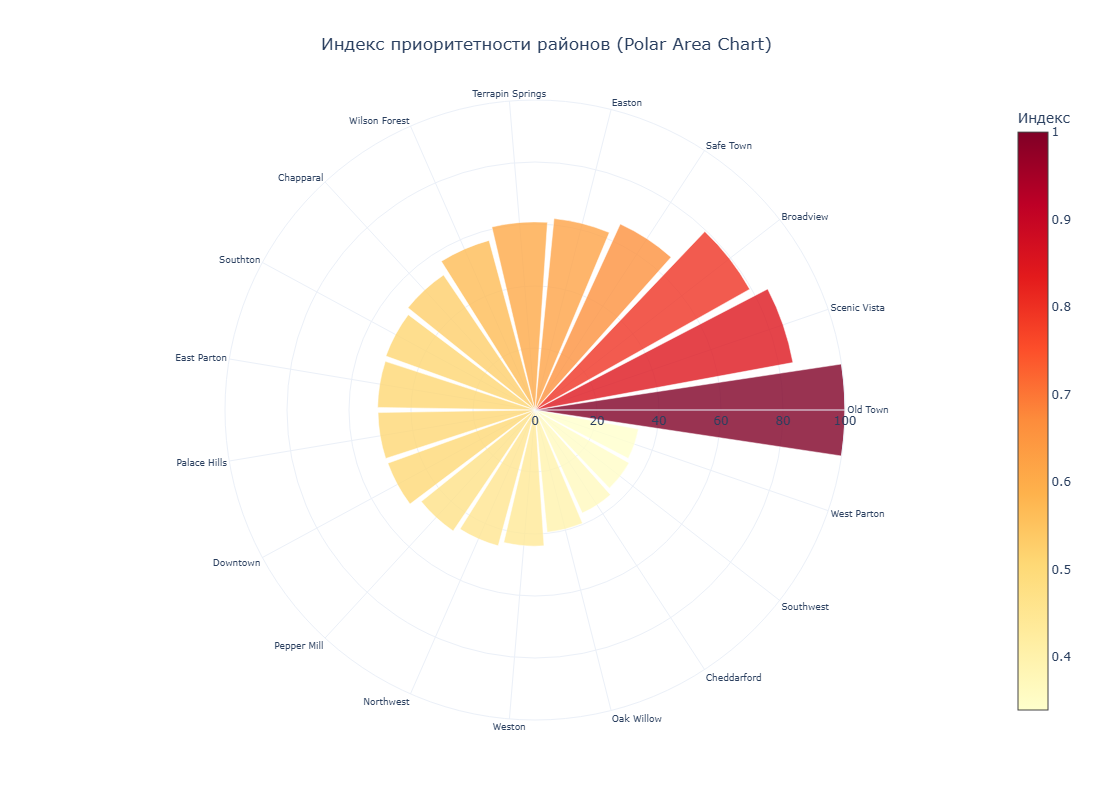

In [19]:
# === РАСЧЁТ ИНДЕКСА ПРИОРИТЕТНОСТИ ===

# 1. Компонента ущерба (нормализованная)
damage_by_area = df.groupby('neighborhood')[damage_cols].mean().mean(axis=1)
damage_score = (damage_by_area / damage_by_area.max())

# 2. Компонента населения (через количество отчётов)
population_score = (reports_by_area / reports_by_area.max())

# 3. Компонента критической инфраструктуры
critical_infrastructure = {
    'Safe Town': 1.0,        # АЭС - максимальный приоритет
    'Downtown': 0.9,         # Trauma + Children Hospital
    'Old Town': 0.6,         # Old Town Hospital
    'Broadview': 0.7,        # Community Hospital
    'Southton': 0.7,         # Eaglepeak Hospital
    'Terrapin Springs': 0.6, # Goldcare Hospital
    'Palace Hills': 0.6,     # Himark General
}

# Создаём датафрейм приоритетов
priority = pd.DataFrame(index=df['neighborhood'].unique())
priority['damage_score'] = damage_score
priority['population_score'] = population_score.reindex(priority.index).fillna(0)
priority['infrastructure_score'] = priority.index.map(
    lambda x: critical_infrastructure.get(x, 0.2)  
)

# Взвешенный индекс приоритетности
priority['priority_index'] = (
    0.5 * priority['damage_score'] + 
    0.3 * priority['population_score'] + 
    0.2 * priority['infrastructure_score']
)

# Нормализация к 0-1
priority['priority_index'] = priority['priority_index'] / priority['priority_index'].max()

print("Индекс приоритетности районов:")
print("="*60)
print(priority.sort_values('priority_index', ascending=False).round(3))

# === POLAR AREA CHART ===
priority_sorted = priority.sort_values('priority_index', ascending=False)

fig_polar = go.Figure()

fig_polar.add_trace(go.Barpolar(
    r=priority_sorted['priority_index'] * 100,
    theta=priority_sorted.index,
    marker=dict(
        color=priority_sorted['priority_index'],
        colorscale='YlOrRd',
        cmin=priority['priority_index'].min(),
        cmax=priority['priority_index'].max(),
        colorbar=dict(title='Индекс')
    ),
    opacity=0.8,
    hovertemplate='<b>%{theta}</b><br>Индекс: %{r:.1f}%<extra></extra>'
))

fig_polar.update_layout(
    title=dict(
        text='Индекс приоритетности районов (Polar Area Chart)',
        x=0.5
    ),
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        ),
        angularaxis=dict(
            tickfont=dict(size=9)
        )
    ),
    width=900,
    height=800,
    template='plotly_white'
)
fig_polar.show()


Три компоненты взвешены так, чтобы:
- Ущерб имел наибольший вес (это основная причина для помощи)
- Население учитывало, скольким людям нужна помощь
- Инфраструктура повышала приоритет стратегических объектов

### Группы приоритетности:

**🔴 ВЫСШИЙ ПРИОРИТЕТ (немедленное реагирование):**
- **Old Town** — максимальный ущерб + 2-е по населению + больница + 
  ремонтные работы усугубили ситуацию + «замолчал» после 2-го толчка
- **Safe Town** — АЭС! Даже умеренный ущерб здесь критичен
- **Scenic Vista** — аномально высокий ущерб + 1-е по населению
- **Downtown** — травматологическая + детская больницы

**🟠 ВЫСОКИЙ ПРИОРИТЕТ:**
- **Broadview** — 3-е по населению + стабильно высокий ущерб
- **Easton** — 4-е по населению + значительные повреждения
- **Southton** — больница Eaglepeak (реанимация)

**🟡 СРЕДНИЙ ПРИОРИТЕТ:**
- **Northwest, Weston, East Parton, Pepper Mill** — 
  средний ущерб, значительное население
- **Terrapin Springs** — больница Goldcare

**🟢 МОНИТОРИНГ + РАЗВЕДКА:**
- **Chapparal** — мало данных, возможные отключения, **нужна разведка**
- **Wilson Forest** — 173 отчёта, невозможно оценить, **нужна разведка**
- **Cheddarford, Oak Willow, West Parton, Southwest, Palace Hills** — 
  низкий ущерб и/или мало населения

### Ключевые принципы:
1. **Молчание ≠ безопасность.** Районы без отчётов получают разведбригады.
2. **АЭС — всегда первый.** Даже при низком ущербе Safe Town получает ресурсы.
3. **Больницы — защитить любой ценой.** Downtown и Southton — медицинское ядро города.
4. **Данные по `medical` ненадёжны.** Нужна прямая связь с больницами, а не краудсорсинг.
5. **Адаптивность.** Приоритеты пересматриваются каждые 2 часа по мере поступления новых данных.